<a href="https://colab.research.google.com/github/pedropauloabr/engenharia_de_prompt_ia/blob/main/Aula08_Automacao_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Este script tem como objetivo principal simular a leitura de temperatura de um sistema.
# Ele também é responsável por alertar o usuário caso a temperatura medida exceda um limite pré-definido.

# Definição da função 'get_system_temperature':
# Esta função é projetada para simular a obtenção da temperatura atual do sistema.
# Em um cenário de uso real, esta função se conectaria a um sensor de hardware (como CPU ou GPU)
# ou a uma API do sistema operacional para coletar dados de temperatura em tempo real.
def get_system_temperature():
    # Inicia um loop infinito que continuará até que uma entrada válida seja fornecida.
    while True:
        try:
            # Solicita ao usuário que insira a temperatura atual do sistema em graus Celsius.
            temp_input = input("Por favor, insira a temperatura atual do sistema em °C: ")
            # Tenta converter a entrada do usuário (que é uma string) para um número decimal (float).
            temperature = float(temp_input)
            # Se a conversão for bem-sucedida, a temperatura é retornada e o loop é encerrado.
            return temperature
        except ValueError:
            # Captura um erro se a entrada do usuário não puder ser convertida para um número (ex: texto).
            # Informa ao usuário que a entrada é inválida e pede para tentar novamente.
            print("Entrada inválida. Por favor, insira um número válido para a temperatura.")

# Chamada da função 'get_system_temperature':
# Esta linha executa a função que solicita a temperatura ao usuário e armazena o valor retornado
# na variável 'temperature'.
temperature = get_system_temperature()

# Exibe a temperatura atual:
# Imprime na console a temperatura que foi inserida pelo usuário, formatada para maior clareza.
print(f"Temperatura atual do sistema: {temperature}°C")

# Lógica de verificação da temperatura:
# Um bloco condicional 'if-else' verifica se a temperatura atual excede o limite de 30°C.
if temperature > 30:
    # Se a condição for verdadeira (temperatura > 30°C), um alerta de superaquecimento é exibido.
    print("ALERTA: Superaquecimento detectado! Temperatura acima de 30°C.")
else:
    # Se a condição for falsa (temperatura <= 30°C), é informado que a temperatura está dentro do normal.
    print("Temperatura do sistema está normal.")

Por favor, insira a temperatura atual do sistema em °C: 80
Temperatura atual do sistema: 80.0°C
ALERTA: Superaquecimento detectado! Temperatura acima de 30°C.


### Organizador de Arquivos por Extensão

Este script Python organiza arquivos em subpastas com base em suas extensões, movendo-os de um diretório de origem para um diretório de destino.

#Criar um programa que organize arquivos bagunçados em pastas automaticamente, baseando-se apenas na extensão do arquivo (ex: .pdf, .jpg, .py, .word.) Use biblioteca os ou shutil.

### Organizador de Arquivos por Extensão (Comentado)

Este script Python utiliza as bibliotecas `os` e `shutil` para automatizar a organização de arquivos. Ele move arquivos de um diretório de origem para subpastas no diretório de destino, criando essas subpastas com base na extensão de cada arquivo.

In [15]:
import os
import shutil

def organize_files_by_extension(source_dir, destination_dir):
    # Garante que o diretório de destino exista.
    # Se o 'destination_dir' não existir, ele será criado. 'exist_ok=True' evita erros se já existir.
    os.makedirs(destination_dir, exist_ok=True)

    # Itera sobre cada item (arquivo ou pasta) no diretório de origem especificado.
    for filename in os.listdir(source_dir):
        # Constrói o caminho completo para o item atual (source_dir/filename).
        file_path = os.path.join(source_dir, filename)

        # Verifica se o item atual é de fato um arquivo e não um diretório.
        if os.path.isfile(file_path):
            # Divide o nome do arquivo em nome base e extensão.
            # Ex: 'documento.pdf' resulta em ('documento', '.pdf').
            file_name, file_extension = os.path.splitext(filename)

            # Determina o nome da pasta com base na extensão.
            # Remove o ponto inicial da extensão (ex: '.pdf' -> 'pdf').
            # Converte para minúsculas para padronizar os nomes das pastas (ex: '.PDF' -> 'pdf').
            # Se o arquivo não tiver extensão, ele será movido para uma pasta chamada 'no_extension'.
            extension_folder_name = file_extension[1:].lower() if file_extension else 'sem_extensao'

            # Constrói o caminho completo para a subpasta de destino para a extensão atual.
            destination_folder = os.path.join(destination_dir, extension_folder_name)

            # Cria a subpasta de destino se ela ainda não existir.
            os.makedirs(destination_folder, exist_ok=True)

            # Constrói o caminho completo onde o arquivo será movido dentro da subpasta de destino.
            destination_file_path = os.path.join(destination_folder, filename)

            try:
                # Move o arquivo do caminho de origem para o caminho de destino.
                # shutil.move() trata tanto arquivos quanto diretórios e pode mover entre sistemas de arquivos.
                shutil.move(file_path, destination_file_path)
                print(f"Movido: {filename} -> {extension_folder_name}/")
            except shutil.Error as e:
                # Captura erros específicos que podem ocorrer durante a operação de movimentação (ex: permissão negada).
                print(f"Erro ao mover {filename}: {e}")
            except Exception as e:
                # Captura quaisquer outros erros inesperados para garantir que o script não pare abruptamente.
                print(f"Ocorreu um erro inesperado ao mover {filename}: {e}")

# --- Exemplo de Uso do Script ---
# Para testar este script, você precisará definir os diretórios de origem e destino.

# 1. Obtenha o diretório de trabalho atual do script.
current_dir = os.getcwd()

# 2. Defina o diretório de origem onde seus arquivos desorganizados estão.
#    Para este exemplo, criaremos uma pasta de teste chamada 'pasta_desorganizada_para_teste'.
source_test_dir = os.path.join(current_dir, 'pasta_desorganizada_para_teste')
# Cria o diretório de teste se ele não existir.
if not os.path.exists(source_test_dir):
    os.makedirs(source_test_dir)

# 3. Criar alguns arquivos fictícios para demonstrar a funcionalidade.
#    Você pode comentar estas linhas se já tiver seus próprios arquivos na pasta de origem.
with open(os.path.join(source_test_dir, 'relatorio_trimestral.pdf'), 'w') as f: f.write('Conteúdo do relatório em PDF')
with open(os.path.join(source_test_dir, 'foto_ferias_verao.jpg'), 'w') as f: f.write('Conteúdo da foto de férias')
with open(os.path.join(source_test_dir, 'meu_primeiro_script.py'), 'w') as f: f.write('print("Olá, mundo!")')
with open(os.path.join(source_test_dir, 'anotacoes_importantes.txt'), 'w') as f: f.write('Este é um arquivo de texto com anotações.')
with open(os.path.join(source_test_dir, 'apresentacao_projeto.pptx'), 'w') as f: f.write('Conteúdo da apresentação do projeto')
with open(os.path.join(source_test_dir, 'documento_sem_extensao'), 'w') as f: f.write('Este arquivo não tem extensão.')


# 4. Defina o diretório de origem que o script irá usar.
#    Mude para o caminho real da sua pasta de origem se não estiver usando o diretório de teste.
source_directory = source_test_dir

# 5. Defina o diretório de destino onde as novas pastas organizadas serão criadas.
#    Mude para o caminho real da sua pasta de destino se desejar.
destination_directory = os.path.join(current_dir, 'pastas_organizadas')

print(f"Iniciando a organização dos arquivos de '{source_directory}' para '{destination_directory}'...")
# 6. Chama a função principal para iniciar o processo de organização.
organize_files_by_extension(source_directory, destination_directory)
print("Organização de arquivos concluída!")

Iniciando a organização dos arquivos de '/content/pasta_desorganizada_para_teste' para '/content/pastas_organizadas'...
Movido: apresentacao_projeto.pptx -> pptx/
Movido: documento_sem_extensao -> sem_extensao/
Movido: foto_ferias_verao.jpg -> jpg/
Movido: meu_primeiro_script.py -> py/
Movido: relatorio_trimestral.pdf -> pdf/
Movido: anotacoes_importantes.txt -> txt/
Organização de arquivos concluída!


#Aula 08_Automação com Inteligência Artifical
Nome: Pedro Paulo

#Desenvolver um script que consulte uma API pública (VIACEP) e retorne as informações de endereço formatas de maneira legível.

### Consulta de Endereço com VIACEP

Este script Python permite consultar informações de endereço utilizando a API pública do VIACEP. O usuário insere um CEP, e o script retorna os dados formatados de maneira legível.

In [19]:
# Importa a biblioteca 'requests' para fazer requisições HTTP a APIs externas.
import requests

# Define a função 'get_address_info' que recebe um CEP como parâmetro.
def get_address_info(cep):
    # Constrói a URL da API do VIACEP para o CEP fornecido.
    # A API do VIACEP retorna dados em formato JSON.
    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        # Faz uma requisição GET para a URL da API.
        # 'requests.get()' envia a requisição e 'response' armazena a resposta do servidor.
        response = requests.get(url)

        # Verifica se a requisição foi bem-sucedida (código de status 200).
        response.raise_for_status() # Lança uma exceção para códigos de status HTTP de erro (4xx ou 5xx).

        # Converte a resposta JSON em um dicionário Python.
        data = response.json()

        # Verifica se a resposta contém um erro do VIACEP (ex: CEP inválido).
        if 'erro' in data and data['erro'] == True:
            return {'error': 'CEP não encontrado ou inválido.'}

        # Retorna os dados do endereço se a consulta for bem-sucedida.
        return data

    except requests.exceptions.HTTPError as e:
        # Captura erros específicos de HTTP (ex: 404 Not Found, 500 Internal Server Error).
        return {'error': f"Erro HTTP: {e}"}
    except requests.exceptions.ConnectionError as e:
        # Captura erros de conexão (ex: sem internet, URL inacessível).
        return {'error': f"Erro de Conexão: {e}"}
    except requests.exceptions.Timeout as e:
        # Captura erros de timeout (requisição demorou demais para responder).
        return {'error': f"Timeout da Requisição: {e}"}
    except requests.exceptions.RequestException as e:
        # Captura qualquer outro erro relacionado à requisição.
        return {'error': f"Erro na Requisição: {e}"}
    except ValueError:
        # Captura erro se a resposta não for um JSON válido.
        return {'error': 'Resposta inválida da API (não é JSON).'}

# Define a função 'format_address' para apresentar os dados de forma legível.
def format_address(address_data):
    # Verifica se há dados de endereço válidos.
    if not address_data or 'error' in address_data:
        return address_data.get('error', 'Não foi possível obter os dados do endereço.')

    # Formata as informações do endereço em uma string.
    formatted_string = f"CEP: {address_data.get('cep')}\n"
    formatted_string += f"Logradouro: {address_data.get('logradouro')}\n"
    formatted_string += f"Complemento: {address_data.get('complemento')}\n" if address_data.get('complemento') else ''
    formatted_string += f"Bairro: {address_data.get('bairro')}\n"
    formatted_string += f"Cidade: {address_data.get('localidade')} - {address_data.get('uf')}\n"
    formatted_string += f"IBGE: {address_data.get('ibge')}\n"
    formatted_string += f"DDD: {address_data.get('ddd')}"

    return formatted_string

# --- Exemplo de Uso ---

# Solicita ao usuário que insira um CEP.
cep_input = input("Por favor, insira um CEP (apenas números, ex: 01001000): ")

# Remove caracteres não numéricos do CEP para garantir o formato correto.
cep_cleaned = ''.join(filter(str.isdigit, cep_input))

# Verifica se o CEP limpo tem o tamanho esperado (8 dígitos para o Brasil).
if len(cep_cleaned) == 8:
    print(f"\nConsultando CEP: {cep_cleaned}...")
    # Chama a função para obter os dados do endereço.
    address = get_address_info(cep_cleaned)

    # Verifica se houve erro na consulta e exibe a mensagem apropriada.
    if 'error' in address:
        print(f"Erro: {address['error']}")
    else:
        # Se não houver erro, formata e exibe o endereço.
        print("\n--- Informações do Endereço ---")
        print(format_address(address))
        print("-------------------------------")
else:
    # Mensagem de erro para CEP com formato inválido.
    print("CEP inválido. Por favor, insira um CEP com 8 dígitos numéricos.")

Por favor, insira um CEP (apenas números, ex: 01001000): 72593210

Consultando CEP: 72593210...

--- Informações do Endereço ---
CEP: 72593-210
Logradouro: Quadra QRI 10
Bairro: Residencial Santos Dumont (Santa Maria)
Cidade: Brasília - DF
IBGE: 5300108
DDD: 61
-------------------------------


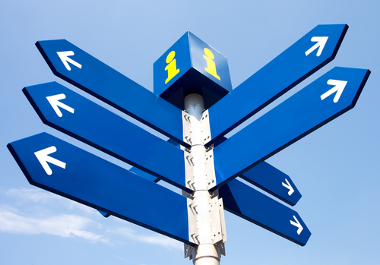